#importando librerias

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import deque

# Create the ventas_demo.csv file with the provided data
ventas_demo = """timestamp,producto,categoria,cantidad,precio_unitario,total_venta
2026-03-25 09:00:00,Teclado,Perifericos,2,350,700
2026-03-25 09:01:00,Mouse,Perifericos,3,200,600
2026-03-25 09:02:00,Laptop,Computo,1,12000,12000
2026-03-25 09:03:00,Memoria USB,Accesorios,4,180,720
2026-03-25 09:04:00,Monitor,Computo,1,3200,3200
2026-03-25 09:05:00,Teclado,Perifericos,1,350,350
2026-03-25 09:06:00,Mouse,Perifericos,2,200,400
2026-03-25 09:07:00,Laptop,Computo,1,11800,11800
2026-03-25 09:08:00,Memoria USB,Accesorios,5,180,900
2026-03-25 09:09:00,Monitor,Computo,1,3200,3200
2026-03-25 09:10:00,Teclado,Perifericos,2,350,700
2026-03-25 09:11:00,Mouse,Perifericos,3,200,600
2026-03-25 09:12:00,Laptop,Computo,1,12500,12500
2026-03-25 09:13:00,Memoria USB,Accesorios,4,180,720
2026-03-25 09:14:00,Monitor,Computo,1,3200,3200
2026-03-25 09:15:00,Teclado,Perifericos,2,350,700
2026-03-25 09:16:00,Mouse,Perifericos,2,200,400
2026-03-25 09:17:00,Laptop,Computo,1,11900,11900
2026-03-25 09:18:00,Memoria USB,Accesorios,6,180,1080
2026-03-25 09:19:00,Monitor,Computo,1,3200,3200
2026-03-25 09:20:00,Laptop,Computo,3,12000,36000
2026-03-25 09:21:00,Mouse,Perifericos,1,200,200
2026-03-25 09:22:00,Teclado,Perifericos,1,350,350
2026-03-25 09:23:00,Memoria USB,Accesorios,2,180,360
2026-03-25 09:24:00,Monitor,Computo,1,3200,3200"""

with open("ventas_demo.csv", "w") as f:
    f.write(ventas_demo)

In [5]:
# =========================
# 1. Cargar dataset
# =========================
df = pd.read_csv("ventas_demo.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

#preparamos la simulacion

In [6]:
# =========================
# 2. Variables para simulación
# =========================
tiempos = []
ventas = []
promedio_movil = []
anomalías_x = []
anomalías_y = []

ventana = deque(maxlen=5)   # promedio móvil de 5 registros
indice_actual = 0

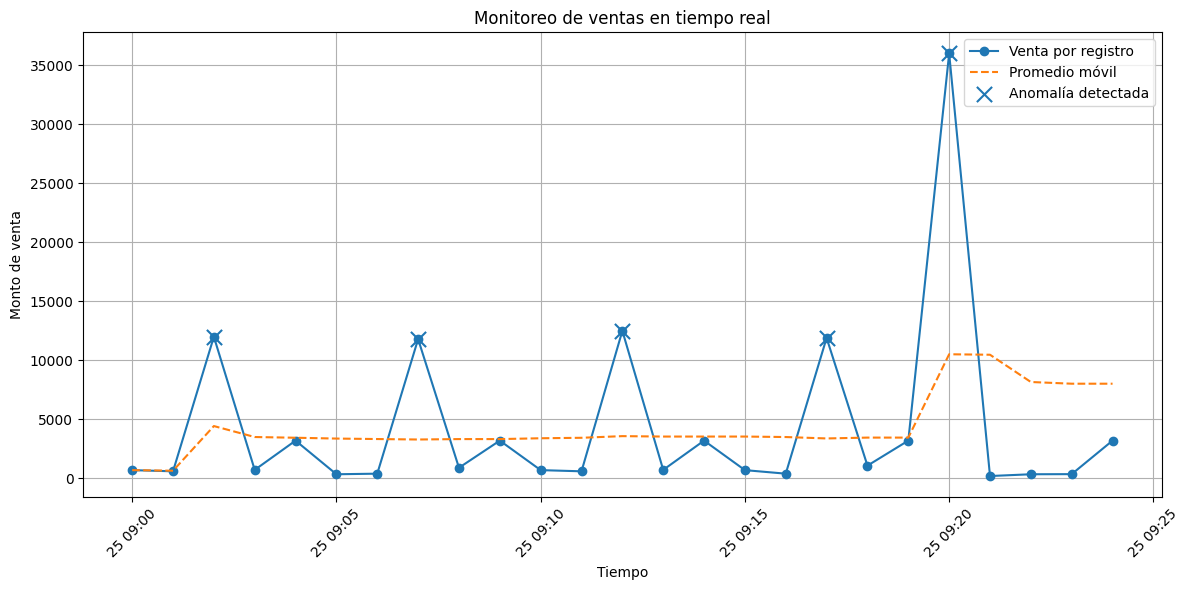

In [18]:
from IPython.display import HTML
from collections import deque # Added for self-containment.

# =========================
# 3. Configuración de la figura
# =========================
fig, ax = plt.subplots(figsize=(12, 6))

# Reset global variables before starting the animation
# These variables are initialized in xg3VtAaeGACq and need to be reset here for re-runs.
tiempos = []
ventas = []
promedio_movil = []
anomalías_x = []
anomalías_y = []
ventana = deque(maxlen=5)   # promedio móvil de 5 registros
indice_actual = 0

def actualizar(frame):
    global indice_actual, tiempos, ventas, promedio_movil, anomalías_x, anomalías_y, ventana

    # Check if frame index is within the DataFrame length
    if indice_actual >= len(df):
        # This return will effectively stop the animation when all data is processed.
        return

    fila = df.iloc[indice_actual]

    tiempo = fila["timestamp"]
    venta = fila["total_venta"]

    tiempos.append(tiempo)
    ventas.append(venta)

    ventana.append(venta)
    promedio = sum(ventana) / len(ventana)
    promedio_movil.append(promedio)

    # Detección simple de anomalía:
    # si la venta actual es 2 veces mayor al promedio móvil previo
    if len(promedio_movil) > 1:
        promedio_prev = promedio_movil[-2]
        if promedio_prev > 0 and venta > promedio_prev * 2:
            anomalías_x.append(tiempo)
            anomalías_y.append(venta)

    # Limpiar gráfica
    ax.clear()

    # Línea de ventas
    ax.plot(tiempos, ventas, marker="o", label="Venta por registro")

    # Línea de promedio móvil
    ax.plot(tiempos, promedio_movil, linestyle="--", label="Promedio móvil")

    # Puntos de anomalías
    if anomalías_x:
        ax.scatter(anomalías_x, anomalías_y, s=120, marker="x", label="Anomalía detectada")

    ax.set_title("Monitoreo de ventas en tiempo real")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Monto de venta")
    ax.legend()
    ax.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()

    indice_actual += 1

# =========================
# 4. Animación
# =========================
# Explicitly pass frames=len(df) to help with animation caching and saving
anim = FuncAnimation(fig, actualizar, frames=len(df), interval=50, repeat=False)

# Para mostrar la animación en Colab
HTML(anim.to_jshtml())

In [11]:
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100.0 # Increase embed limit to 100 MB

In [9]:
from sklearn.ensemble import IsolationForest

datos_modelo = df[["total_venta"]].copy()

modelo = IsolationForest(contamination=0.1, random_state=42)
df["anomalia"] = modelo.fit_predict(datos_modelo)

print(df[["timestamp", "total_venta", "anomalia"]])

             timestamp  total_venta  anomalia
0  2026-03-25 09:00:00          700         1
1  2026-03-25 09:01:00          600         1
2  2026-03-25 09:02:00        12000         1
3  2026-03-25 09:03:00          720         1
4  2026-03-25 09:04:00         3200         1
5  2026-03-25 09:05:00          350         1
6  2026-03-25 09:06:00          400         1
7  2026-03-25 09:07:00        11800        -1
8  2026-03-25 09:08:00          900         1
9  2026-03-25 09:09:00         3200         1
10 2026-03-25 09:10:00          700         1
11 2026-03-25 09:11:00          600         1
12 2026-03-25 09:12:00        12500        -1
13 2026-03-25 09:13:00          720         1
14 2026-03-25 09:14:00         3200         1
15 2026-03-25 09:15:00          700         1
16 2026-03-25 09:16:00          400         1
17 2026-03-25 09:17:00        11900         1
18 2026-03-25 09:18:00         1080         1
19 2026-03-25 09:19:00         3200         1
20 2026-03-25 09:20:00        3600